# Usporedba modela: Isolation Forest vs. duboki autoenkoder

Ova bilježnica objedinjuje rezultate obje pojedinačno istrenirane i evaluirane bilježnice (isolation_forest.ipynb i autoencoder.ipynb) radi izravne usporedbe na istom testnom skupu (30 %, kronološki posljednji dio podatkovnog skupa). Ista podjela kao u isolation_forest.ipynb i autoencoder.ipynb. Ne trenira modele iznova, nego učitava već istrenirane, spremljene modele iz obje bilježnice

Datoteke isolation_forest_model.pkl, amount_scaler_if.pkl i time_scaler_if.pkl iz isolation_forest.ipynb, te autoencoder_model.keras iz autoencoder_keras_tensor.ipynb potrebno je učitati u runtime ove bilježnice (ćelija u nastavku otvara sučelje za učitavanje datoteka).

In [1]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
#!pip install -q joblib
!pip install -q tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from tensorflow import keras

RANDOM_STATE = 42

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## 1. Priprema testnog skupa

Identična podjela (63 % učenje / 7 % validacija / 30 % testiranje, kronološki) kao u obje pojedinačne bilježnice. Koristi se samo zadnjih 30 % (testni skup).

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")

n = len(df)
train_end = int(n * 0.63)
val_end = int(n * 0.70)

train_df = df.iloc[:train_end].copy()
test_df = df.iloc[val_end:].copy()

amount_scaler = RobustScaler()
amount_scaler.fit(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
time_scaler.fit(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Test: (85443, 30), Fraud rate: 0.1264 %


## 2. Učitavanje istreniranih modela i pragova

Pragovi su preuzeti izravno iz pojedinačnih bilježnica. Pokretanjem sljedeće ćelije potrebno je učitati sve četiri datoteke navedene u uvodu.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving amount_scaler_if.pkl to amount_scaler_if.pkl
Saving autoencoder_model.keras to autoencoder_model.keras
Saving isolation_forest_model.pkl to isolation_forest_model.pkl
Saving time_scaler_if.pkl to time_scaler_if.pkl


In [4]:
IF_THRESHOLD = 0.4959
AE_THRESHOLD = 1.5669

iso_forest = joblib.load('isolation_forest_model.pkl')
autoencoder = keras.models.load_model('autoencoder_model.keras')

print("Both models uploaded successfully.")

Both models uploaded successfully.


## 3. Izračun anomalijskih rezultata

Za Isolation Forest koristi se već ustaljena konvencija (veći rezultat = veća anomalnost), a za autoenkoder pogreška rekonstrukcije (srednja kvadratna pogreška po transakciji).



In [5]:
if_scores = -iso_forest.score_samples(X_test)

ae_reconstructed = autoencoder.predict(X_test, verbose=0)
ae_scores = np.mean(np.square(X_test - ae_reconstructed), axis=1)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


## 4. Usporedba prema evaluacijskim metrikama

Pragovi ispod odgovaraju finalnim konfiguracijama usvojenima u poglavljima 4.4.3. i 4.5.2. završnog rada.

In [6]:
if_pred = (if_scores >= IF_THRESHOLD).astype(int)
ae_pred = (ae_scores > AE_THRESHOLD).astype(int)

comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC'],
    'Isolation Forest': [
        precision_score(y_test, if_pred),
        recall_score(y_test, if_pred),
        f1_score(y_test, if_pred),
        roc_auc_score(y_test, if_scores),
        average_precision_score(y_test, if_scores)
    ],
    'Autoencoder': [
        precision_score(y_test, ae_pred),
        recall_score(y_test, ae_pred),
        f1_score(y_test, ae_pred),
        roc_auc_score(y_test, ae_scores),
        average_precision_score(y_test, ae_scores)
    ]
})
comparison

,Metric,Isolation Forest,Autoencoder
0,Precision,0.048917,0.068664
1,Recall,0.648148,0.509259
2,F1-score,0.090968,0.121012
3,ROC-AUC,0.942573,0.935755
4,PR-AUC,0.048570,0.065618


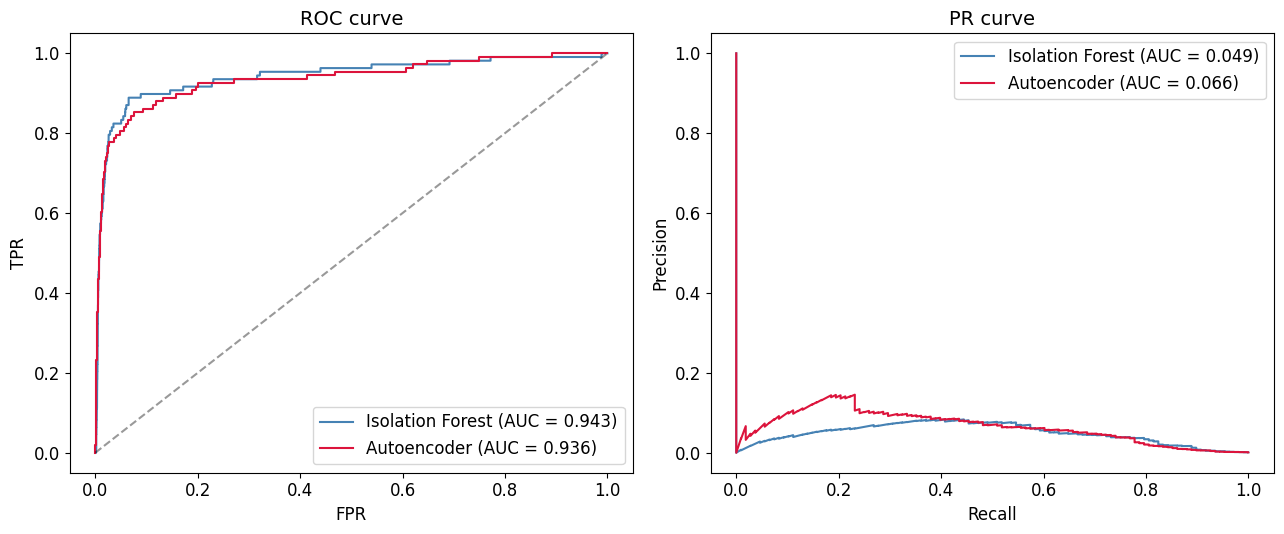

In [7]:
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
prec_if, rec_if, _ = precision_recall_curve(y_test, if_scores)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, ae_scores)

roc_auc_if = roc_auc_score(y_test, if_scores)
roc_auc_ae = roc_auc_score(y_test, ae_scores)
pr_auc_if = average_precision_score(y_test, if_scores)
pr_auc_ae = average_precision_score(y_test, ae_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})', color='steelblue')
axes[0].plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {roc_auc_ae:.3f})', color='crimson')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_if, prec_if, label=f'Isolation Forest (AUC = {pr_auc_if:.3f})', color='steelblue')
axes[1].plot(rec_ae, prec_ae, label=f'Autoencoder (AUC = {pr_auc_ae:.3f})', color='crimson')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()

plt.tight_layout()
plt.show()

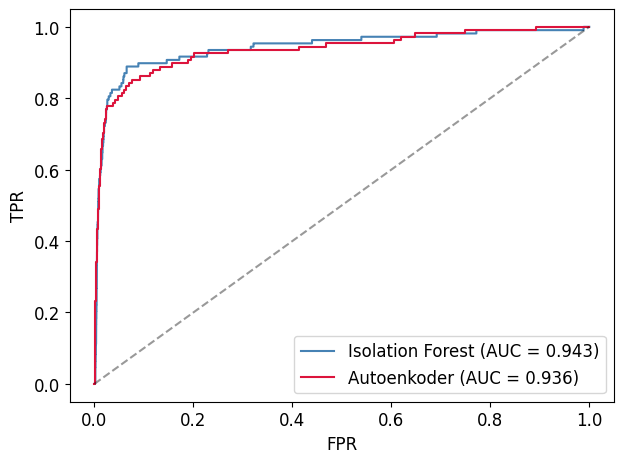

In [8]:
plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})', color='steelblue')
plt.plot(fpr_ae, tpr_ae, label=f'Autoenkoder (AUC = {roc_auc_ae:.3f})', color='crimson')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curves.png', dpi=300, bbox_inches='tight')
plt.show()

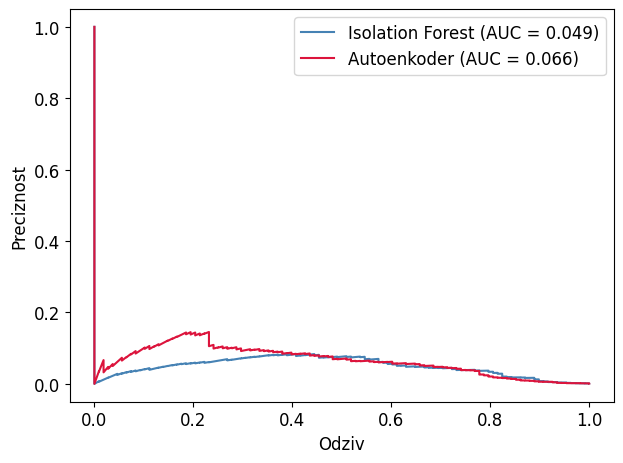

In [9]:
plt.plot(rec_if, prec_if, label=f'Isolation Forest (AUC = {pr_auc_if:.3f})', color='steelblue')
plt.plot(rec_ae, prec_ae, label=f'Autoenkoder (AUC = {pr_auc_ae:.3f})', color='crimson')
plt.xlabel('Odziv')
plt.ylabel('Preciznost')
plt.legend()
plt.tight_layout()
plt.savefig('pr-curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Usporedba vremena obrade

Mjerenje se provodi na hardveru dodijeljenom u trenutnoj Colab sesiji (dijeljeni CPU).

Svaki model se mjeri 5 puta, obradom cijelog testnog skupa odjednom (skupna, ne pojedinačna obrada), a prosjek se dijeli brojem transakcija radi procjene prosječnog vremena po transakcijski.

Napomena: apsolutne vrijednosti ovise o hardveru na kojem se bilježnica izvršava (u Colab okruženju to je dijeljeni CPU), pa je usporedba između dva modela na istom stroju informativnija od same apsolutne brojke.

In [10]:
import platform
print("Processor/Environment:", platform.processor() or "N/A (Colab assigns a generic name by default)")

N_RUNS = 5

if_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = iso_forest.score_samples(X_test)
    if_times.append(time.perf_counter() - start)

ae_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = autoencoder.predict(X_test, verbose=0)
    ae_times.append(time.perf_counter() - start)

if_avg_total = np.mean(if_times)
ae_avg_total = np.mean(ae_times)
if_per_tx_ms = (if_avg_total / len(X_test)) * 1000
ae_per_tx_ms = (ae_avg_total / len(X_test)) * 1000

timing_comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder'],
    'Average total time (s)': [if_avg_total, ae_avg_total],
    'Average time per transaction (ms)': [if_per_tx_ms, ae_per_tx_ms]
})
timing_comparison

Processor/Environment: x86_64


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


,Model,Average total time (s),Average time per transaction (ms)
0,Isolation Forest,1.217290,0.014247
1,Autoencoder,5.018989,0.058741


## 6. Preklapanje detekcija i provjera potencijala združivanja

In [11]:
fraud_idx = np.where(y_test == 1)[0]

if_hits = set(fraud_idx[if_pred[fraud_idx] == 1])
ae_hits = set(fraud_idx[ae_pred[fraud_idx] == 1])

both = if_hits & ae_hits
only_if = if_hits - ae_hits
only_ae = ae_hits - if_hits
missed_by_both = set(fraud_idx) - (if_hits | ae_hits)

print(f"Total number of frauds in test: {len(fraud_idx)}")
print(f"Recognised by both models: {len(both)}")
print(f"Recognised just by Isolation Foresta: {len(only_if)}")
print(f"Recognised just by autoencodera: {len(only_ae)}")
print(f"Missed by both models: {len(missed_by_both)}")

Total number of frauds in test: 108
Recognised by both models: 47
Recognised just by Isolation Foresta: 23
Recognised just by autoencodera: 8
Missed by both models: 30


In [12]:
ensemble_pred = ((if_pred == 1) | (ae_pred == 1)).astype(int)

ensemble_comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Isolation Forest': [
        precision_score(y_test, if_pred),
        recall_score(y_test, if_pred),
        f1_score(y_test, if_pred)
    ],
    'Autoencoder': [
        precision_score(y_test, ae_pred),
        recall_score(y_test, ae_pred),
        f1_score(y_test, ae_pred)
    ],
    'Ensemble (OR)': [
        precision_score(y_test, ensemble_pred),
        recall_score(y_test, ensemble_pred),
        f1_score(y_test, ensemble_pred)
    ]
})
ensemble_comparison

,Metric,Isolation Forest,Autoencoder,Ensemble (OR)
0,Precision,0.048917,0.068664,0.045270
1,Recall,0.648148,0.509259,0.722222
2,F1-score,0.090968,0.121012,0.085199
